# Neural network: residual MLP with `TimeLinear`

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import sys
sys.path.append('..')

from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.data import BreathDataset, BreathDatasetCollator, add_features, load_data, make_loaders
from src.metrics import evaluate
from src.nn import train
from src.postprocess import snap
from src.tracking import EXPERIMENT_NAME, TRACKING_URI

## Data

In [7]:
train_loader, val_loader, info = make_loaders('../data/train.csv')
len(train_loader.dataset), len(val_loader.dataset), len(info['feature_cols'])

(60360, 15090, 31)

## Training

In [8]:
EPOCHS = 150
RUN_NAME = 'nn_time-v1'

model, best_val_mae = train(train_loader, val_loader, len(info['feature_cols']), RUN_NAME, max_epochs=EPOCHS)
best_val_mae

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/models exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_conn

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


0.36642804741859436

## Validation

Metrics on `u_out == 0`, same `evaluate` as LGBM.

In [9]:
predictor = L.Trainer(accelerator='auto', logger=False, enable_progress_bar=False)


def predict(loader):
    return torch.cat(predictor.predict(model, loader)).cpu().numpy().ravel()


val_pred = predict(val_loader)
val_true = val_loader.dataset.target.numpy().ravel()
val_u_out = (~val_loader.dataset.mask).numpy().ravel().astype(int)

metrics = {
    'raw': evaluate(val_true, val_pred, val_u_out),
    'snapped': evaluate(val_true, snap(val_pred), val_u_out),
}
pd.DataFrame(metrics).T

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


,ME,MAE,RMSE,R2
raw,0.001666,0.366428,0.589902,0.995884
snapped,0.001652,0.365776,0.590216,0.995880


In [10]:
mlflow.set_tracking_uri(TRACKING_URI)
client = mlflow.MlflowClient()
run_id = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME], filter_string=f"tags.mlflow.runName = '{RUN_NAME}'"
).iloc[0].run_id

for k, v in metrics['raw'].items():
    client.log_metric(run_id, k, float(v))

np.save('../submissions/nn_val_pred.npy', val_pred)

## Results

In [11]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
runs[['tags.mlflow.runName', 'metrics.MAE', 'metrics.RMSE', 'metrics.ME', 'metrics.R2']].dropna(
    subset=['metrics.MAE']
).sort_values('metrics.MAE')

,tags.mlflow.runName,metrics.MAE,metrics.RMSE,metrics.ME,metrics.R2
0,nn_time-v1,0.366428,0.589902,0.001666,0.995884
2,lgbm_inspiration-v1,0.615717,0.983579,0.012344,0.988558
3,lgbm_all_rows-v3,0.619880,0.990268,0.014718,0.988402


### Parameter log

In [12]:
nn_runs = runs[runs['tags.mlflow.runName'].str.startswith('nn')]
nn_runs.filter(regex=r'tags.mlflow.runName|^params\.|metrics.val_mae|metrics.MAE$')

,metrics.val_mae,metrics.MAE,params.d,params.time_mixing,params.lr,params.n_features,params.dropout,params.n_blocks,params.weight_decay,params.max_depth,...,params.reg_lambda,params.random_state,params.subsample_freq,params.num_boost_round,params.early_stopping_rounds,params.min_child_samples,params.boosting_type,params.num_threads,params.min_child_weight,tags.mlflow.runName
0,0.368199,0.366428,128,True,0.001,31,0.1,6,0.01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nn_time-v1
1,1.215906,NaN,128,True,0.001,31,0.1,6,0.01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nn_time-v1


## Gradient flow

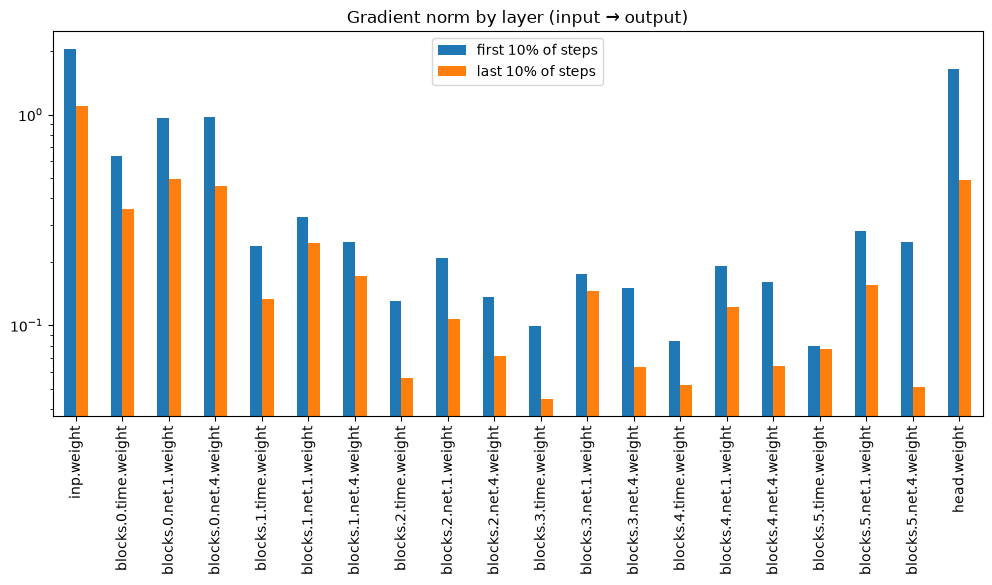

In [13]:
def history(key):
    return pd.Series({m.step: m.value for m in client.get_metric_history(run_id, key)}).sort_index()


weights = [n for n, p in model.model.named_parameters() if p.ndim >= 2]  # input → output order
grads = pd.DataFrame({n: history(f'grad_2.0_norm/{n}') for n in weights})

n = max(len(grads) // 10, 1)
pd.DataFrame({'first 10% of steps': grads.iloc[:n].mean(), 'last 10% of steps': grads.iloc[-n:].mean()}).plot.bar(
    figsize=(12, 5), logy=True, title='Gradient norm by layer (input → output)'
);

## `TimeLinear` weights (block 0)

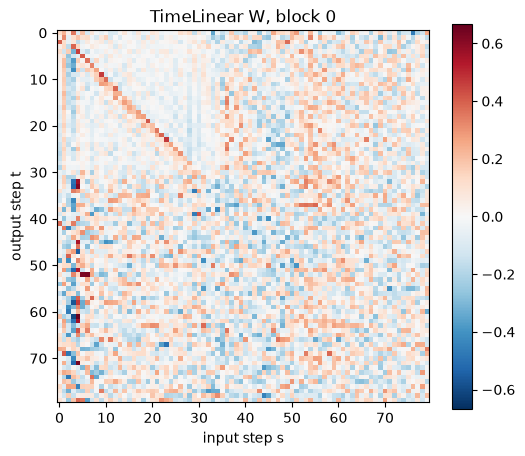

In [14]:
W = model.model.blocks[0].time.weight.detach().cpu()
lim = W.abs().max()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(W, cmap='RdBu_r', vmin=-lim, vmax=lim)
ax.set(xlabel='input step s', ylabel='output step t', title='TimeLinear W, block 0')
fig.colorbar(im);

## Kaggle submission

In [15]:
test_df = add_features(load_data('../data/test.csv'))
test_loader = DataLoader(
    BreathDataset(test_df, info['feature_cols'], info['mean'], info['std']),  
    batch_size=1024,
    collate_fn=BreathDatasetCollator(),
)
test_pred = predict(test_loader)

Path('../submissions').mkdir(exist_ok=True)
for name, p in {'nn_raw': test_pred, 'nn_snap': snap(test_pred)}.items():
    pd.DataFrame({'id': test_df['id'], 'pressure': p}).sort_values('id').to_csv(
        f'../submissions/{name}.csv', index=False
    )

/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


In [16]:
!kaggle competitions submit -c ventilator-pressure-prediction -f ../submissions/nn_raw.csv -m "nn TimeLinear raw"
!kaggle competitions submit -c ventilator-pressure-prediction -f ../submissions/nn_snap.csv -m "nn TimeLinear + ADC snap"
!kaggle competitions submissions -c ventilator-pressure-prediction | head -5

100%|██████████████████████████████████████| 66.7M/66.7M [00:09<00:00, 7.50MB/s]
Successfully submitted to Google Brain - Ventilator Pressure PredictionWarning: Looks like you're using an outdated `kaggle` version (installed: 2.0.0), please consider upgrading to the latest version (2.2.2)
100%|██████████████████████████████████████| 66.5M/66.5M [00:03<00:00, 20.5MB/s]
Successfully submitted to Google Brain - Ventilator Pressure PredictionWarning: Looks like you're using an outdated `kaggle` version (installed: 2.0.0), please consider upgrading to the latest version (2.2.2)
fileName               date                        description                                   status                     publicScore  privateScore  
---------------------  --------------------------  --------------------------------------------  -------------------------  -----------  ------------  
nn_snap.csv            2026-10-01 19:49:25.540000  nn TimeLinear + ADC snap                      SubmissionStatus.PE

The NN is adequate: val MAE 0.366 vs 0.616 for LGBM (−40%), with no systematic bias (ME ≈ 0.002). Gradient flow is healthy: no vanishing or exploding gradients, and the norms decrease by the end of training. The deeper TimeLinear layers get the smallest gradients, so a 4-block model would likely work as well and train faster. TimeLinear learned a clear structure focused on the inspiratory steps.